## 📦 Import Libraries

In this section, we import all the necessary libraries required for data manipulation, visualization, preprocessing, and model building.

In [134]:

#  Data Handling
import pandas as pd
import numpy as np
#  Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#  Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer
#  Data Splitting
from sklearn.model_selection import train_test_split
#  Models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
#  Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
# # Deep Learning
from tensorflow.keras import layers, models, callbacks
## SMOTE(Synthetic Minority OverSampling Technique)
from imblearn.over_sampling import RandomOverSampler
## saving and loading) of your data preprocessing assets
import joblib

# 📥 Data Loading

In [135]:
df = pd.read_csv('fda_adverse_events_2015_2026_CLEAN.csv')

# 🔍 Initial Data Exploration

#### We explore the dataset to understand its structure, features, and basic properties.

In [136]:
df.head()

,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,NaN,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,NaN,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,NaN,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,NaN,False,False,False,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),NaN,Unknown,Female,NaN,GB,4053


In [137]:
#print the shape(Rows and Columns of Datatset)
df.shape

(528000, 30)

In [138]:
# Print Column names
df.columns

Index(['report_id', 'receive_date', 'year', 'month', 'quarter', 'serious',
       'serious_flags', 'is_fatal', 'is_hospitalized', 'is_life_threat',
       'is_disabling', 'reactions', 'primary_reaction', 'reaction_outcomes',
       'patient_recovered', 'num_reactions', 'suspect_drug', 'brand_name',
       'drug_route', 'drug_indication', 'manufacturer', 'pharm_class',
       'num_drugs', 'drug_count_category', 'patient_age_years', 'age_group',
       'patient_sex', 'patient_weight_kg', 'country', 'report_age_days'],
      dtype='object')

In [139]:
df.head()

,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,NaN,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,NaN,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,NaN,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,NaN,False,False,False,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),NaN,Unknown,Female,NaN,GB,4053


In [140]:
# Print Column info => Column name , No Null values, DataTypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528000 entries, 0 to 527999
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   report_id            528000 non-null  int64  
 1   receive_date         528000 non-null  object 
 2   year                 528000 non-null  int64  
 3   month                528000 non-null  int64  
 4   quarter              528000 non-null  object 
 5   serious              528000 non-null  object 
 6   serious_flags        226894 non-null  object 
 7   is_fatal             528000 non-null  bool   
 8   is_hospitalized      528000 non-null  bool   
 9   is_life_threat       528000 non-null  bool   
 10  is_disabling         528000 non-null  bool   
 11  reactions            528000 non-null  object 
 12  primary_reaction     528000 non-null  object 
 13  reaction_outcomes    528000 non-null  object 
 14  patient_recovered    528000 non-null  bool   
 15  num_reactions    

# 🧩 Missing Values Analysis
#### We check for missing/null values in the dataset.

In [141]:
df.isnull

<bound method DataFrame.isnull of         report_id receive_date  year  month quarter serious    serious_flags  \
0        10004718   2015-02-11  2015      2  2015Q1     Yes  Hospitalization   
1        10004926   2015-02-13  2015      2  2015Q1     Yes  Hospitalization   
2        10005223   2015-02-19  2015      2  2015Q1     Yes  Hospitalization   
3        10005378   2015-02-17  2015      2  2015Q1     Yes  Hospitalization   
4        10005980   2015-02-21  2015      2  2015Q1     Yes              NaN   
...           ...          ...   ...    ...     ...     ...              ...   
527995   22807486   2025-12-29  2025     12  2025Q4     Yes              NaN   
527996   22808018   2025-12-08  2025     12  2025Q4      No              NaN   
527997   22810302   2025-12-31  2025     12  2025Q4      No              NaN   
527998   22810346   2025-12-24  2025     12  2025Q4      No              NaN   
527999   22811868   2025-12-09  2025     12  2025Q4     Yes              NaN   

     

In [142]:
df.isnull()

,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527995,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
527996,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
527997,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
527998,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [143]:
df.isnull().sum()

report_id                   0
receive_date                0
year                        0
month                       0
quarter                     0
serious                     0
serious_flags          301106
is_fatal                    0
is_hospitalized             0
is_life_threat              0
is_disabling                0
reactions                   0
primary_reaction            0
reaction_outcomes           0
patient_recovered           0
num_reactions               0
suspect_drug                0
brand_name                  0
drug_route                  0
drug_indication             0
manufacturer                0
pharm_class                 0
num_drugs                   0
drug_count_category         0
patient_age_years      151509
age_group                   0
patient_sex                 0
patient_weight_kg      379923
country                     0
report_age_days             0
dtype: int64

# ✨ Data Cleaning

#### In this step, we handle missing values and remove unnecessary features.

In [144]:
# Drop Un-necessary columns => that has not relevant info make only make noise
df = df.drop([
              'report_id',
              'receive_date',
              'year','month',
              'quarter',
              'manufacturer',
              'drug_count_category',
              'patient_age_years',
              'patient_weight_kg',
              'country',
              'report_age_days'
             ],axis=1 )

In [145]:
# Drop Un-necessary columns => that has not relevant info make only make noise . These columns have post_reactions info.
df = df.drop([
              'serious_flags',
              'is_fatal',
              'is_hospitalized',
              'is_life_threat',
              'is_disabling',  
              'reactions',      
              'primary_reaction',
              'reaction_outcomes',
              'patient_recovered',       
              'num_reactions',
              'drug_route',
             ],axis=1 )

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528000 entries, 0 to 527999
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   serious          528000 non-null  object
 1   suspect_drug     528000 non-null  object
 2   brand_name       528000 non-null  object
 3   drug_indication  528000 non-null  object
 4   pharm_class      528000 non-null  object
 5   num_drugs        528000 non-null  int64 
 6   age_group        528000 non-null  object
 7   patient_sex      528000 non-null  object
dtypes: int64(1), object(7)
memory usage: 32.2+ MB


## 🔤 Categorical Data Encoding

#### In this step, we convert categorical variables into numerical form using Label Encoding so that machine learning models can process them.

In [147]:
# Print no of values in => df['serious']
df['serious'].value_counts()

serious
Yes    395000
No     133000
Name: count, dtype: int64

In [148]:
serious_le = LabelEncoder()
df['serious'] = serious_le.fit_transform(df['serious'])
df['serious'].value_counts()

serious
1    395000
0    133000
Name: count, dtype: int64

In [149]:
# # 2. Save it immediately
# joblib.dump(serious_le, 'serious_encoder.joblib')

# print("Success! 'serious_encoder.joblib' is ready.")

In [150]:
df['suspect_drug'].value_counts()

suspect_drug
TOFACITINIB                        13807
RISPERIDONE                        13487
RIVAROXABAN                        12968
AVANDIA                            10091
ETANERCEPT                          8751
                                   ...  
PENICILLIN-V /00001801/                1
TRIFLUOPERAZINE HCL TABLETS USP        1
ALPHA-AMYLASE  SWINE PANCREAS          1
CORIFACT                               1
DIHYDROERGOTAMINE MESYLATE             1
Name: count, Length: 9828, dtype: int64

In [151]:
suspect_drug_le = LabelEncoder()
df['suspect_drug'] = suspect_drug_le.fit_transform(df['suspect_drug'])
df['suspect_drug'].value_counts()

suspect_drug
8986    13807
7966    13487
8004    12968
1067    10091
3611     8751
        ...  
7186        1
9156        1
442         1
2476        1
2950        1
Name: count, Length: 9828, dtype: int64

In [152]:
# # 2. Save it immediately
# joblib.dump(suspect_drug_le, 'suspect_drug_encoder.joblib')

# print("Success! 'suspect_drug_encoder.joblib' is ready.")

In [153]:
df['brand_name'].value_counts()

brand_name
Unknown                                                   76027
XARELTO                                                   12789
RISPERDAL                                                 11355
ENBREL                                                     8751
DUPIXENT                                                   8246
                                                          ...  
TRAMADOL HYDROCHLORIDE AND ACETAMINOPHEN                      1
JAVYGTOR; SAPROPTERIN DIHYDROCHLORIDE; ZELVYSIA; KUVAN        1
GOODYS EXTRA STRENGTH                                         1
CARBATROL                                                     1
DIHYDROERGOTAMINE MESYLATE; BREKIYA; ATZUMI; TRUDHESA         1
Name: count, Length: 2782, dtype: int64

In [154]:
brand_name_le = LabelEncoder()
df['brand_name'] = brand_name_le.fit_transform(df['brand_name'])
df['brand_name'].value_counts()

brand_name
2540    76027
2665    12789
2133    11355
849      8751
800      8246
        ...  
2446        1
1278        1
1099        1
432         1
744         1
Name: count, Length: 2782, dtype: int64

In [155]:
# # 2. Save it immediately
# joblib.dump(brand_name_le, 'brand_encoder.joblib')

# print("Success! 'brand_encoder.joblib' is ready.")

In [156]:
df['drug_indication'].value_counts()

drug_indication
Unknown                                 70172
Product Used For Unknown Indication     63460
Rheumatoid Arthritis                    29064
Multiple Sclerosis                      16878
Diabetes Mellitus                       12636
                                        ...  
Trace Element Deficiency                    1
Becker^S Muscular Dystrophy                 1
Immune Enhancement Therapy                  1
Insulin-Like Growth Factor Decreased        1
Morbihan Disease                            1
Name: count, Length: 5385, dtype: int64

In [157]:
drug_indication_le = LabelEncoder()
df['drug_indication'] = drug_indication_le.fit_transform(df['drug_indication'])
df['drug_indication'].value_counts()

drug_indication
5162    70172
4184    63460
4494    29064
3278    16878
1416    12636
        ...  
5067        1
552         1
2523        1
2634        1
3247        1
Name: count, Length: 5385, dtype: int64

In [158]:
# # 2. Save it immediately
# joblib.dump(drug_indication_le, 'drug_indication_encoder.joblib')

# print("Success! 'drug_indication_encoder.joblib' is ready.")

In [159]:
df['pharm_class'].value_counts()

pharm_class
Unknown                                                           235513
Tumor Necrosis Factor Blocker [EPC]                                27036
Atypical Antipsychotic [EPC]                                       19268
Factor Xa Inhibitor [EPC]                                          13839
Kinase Inhibitor [EPC]                                             12482
                                                                   ...  
Antiprotozoal [EPC]                                                    1
Calcitonin Gene-related Peptide Receptor Antagonist [EPC]              1
Anthrax Protective Antigen-directed Antibody [EPC]                     1
Progesterone [EPC]; Estrogen [EPC]                                     1
Bispecific gp100 Peptide-HLA-directed CD3 T Cell Engager [EPC]         1
Name: count, Length: 448, dtype: int64

In [160]:
pharm_class_le = LabelEncoder()
df['pharm_class'] = pharm_class_le.fit_transform(df['pharm_class'])
df['pharm_class'].value_counts()

pharm_class
417    235513
414     27036
57      19268
160     13839
236     12482
        ...  
47          1
87          1
27          1
333         1
70          1
Name: count, Length: 448, dtype: int64

In [161]:
# # 2. Save it immediately
# joblib.dump(pharm_class_le, 'pharm_class_encoder.joblib')

# print("Success! 'pharm_class_encoder.joblib' is ready.")

In [162]:
df['age_group'].value_counts()

age_group
Middle-Aged(41-65)    166278
Unknown               152337
Senior(66-80)         108781
Adult(19-40)           53277
Elderly(81+)           25842
Child(3-12)             9767
Teen(13-18)             8617
Infant(0-2)             3101
Name: count, dtype: int64

In [163]:
age_group_le = LabelEncoder()
df['age_group'] = age_group_le.fit_transform(df['age_group'])
df['age_group'].value_counts()

age_group
4    166278
7    152337
5    108781
0     53277
2     25842
1      9767
6      8617
3      3101
Name: count, dtype: int64

In [164]:
# # 2. Save it immediately
# joblib.dump(age_group_le, 'age_group_encoder.joblib')

# print("Success! 'age_group_encoder.joblib' is ready.")

In [165]:
df['patient_sex'].value_counts()

patient_sex
Female     279155
Male       198932
Unknown     49913
Name: count, dtype: int64

In [166]:
patient_sex_le = LabelEncoder()
df['patient_sex'] = patient_sex_le.fit_transform(df['patient_sex'])
df['patient_sex'].value_counts()

patient_sex
0    279155
1    198932
2     49913
Name: count, dtype: int64

In [167]:
# # 2. Save it immediately
# joblib.dump(patient_sex_le, 'patient_sex_encoder.joblib')

# print("Success! 'patient_sex_encoder.joblib' is ready.")

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528000 entries, 0 to 527999
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   serious          528000 non-null  int32
 1   suspect_drug     528000 non-null  int32
 2   brand_name       528000 non-null  int32
 3   drug_indication  528000 non-null  int32
 4   pharm_class      528000 non-null  int32
 5   num_drugs        528000 non-null  int64
 6   age_group        528000 non-null  int32
 7   patient_sex      528000 non-null  int32
dtypes: int32(7), int64(1)
memory usage: 18.1 MB


# Correlation

In [169]:
correlation = df.corr()
correlation

,serious,suspect_drug,brand_name,drug_indication,pharm_class,num_drugs,age_group,patient_sex
serious,1.000000,0.007610,0.061437,-0.069400,0.042519,0.126050,-0.102226,0.066596
suspect_drug,0.007610,1.000000,0.268111,-0.013977,-0.118386,0.008196,-0.005142,-0.015862
brand_name,0.061437,0.268111,1.000000,-0.037301,0.111968,-0.016539,-0.008761,0.026889
drug_indication,-0.069400,-0.013977,-0.037301,1.000000,0.055658,0.010473,0.022705,-0.078815
pharm_class,0.042519,-0.118386,0.111968,0.055658,1.000000,0.000107,0.029950,-0.021504
num_drugs,0.126050,0.008196,-0.016539,0.010473,0.000107,1.000000,-0.015973,-0.000744
age_group,-0.102226,-0.005142,-0.008761,0.022705,0.029950,-0.015973,1.000000,0.253717
patient_sex,0.066596,-0.015862,0.026889,-0.078815,-0.021504,-0.000744,0.253717,1.000000


<Axes: >

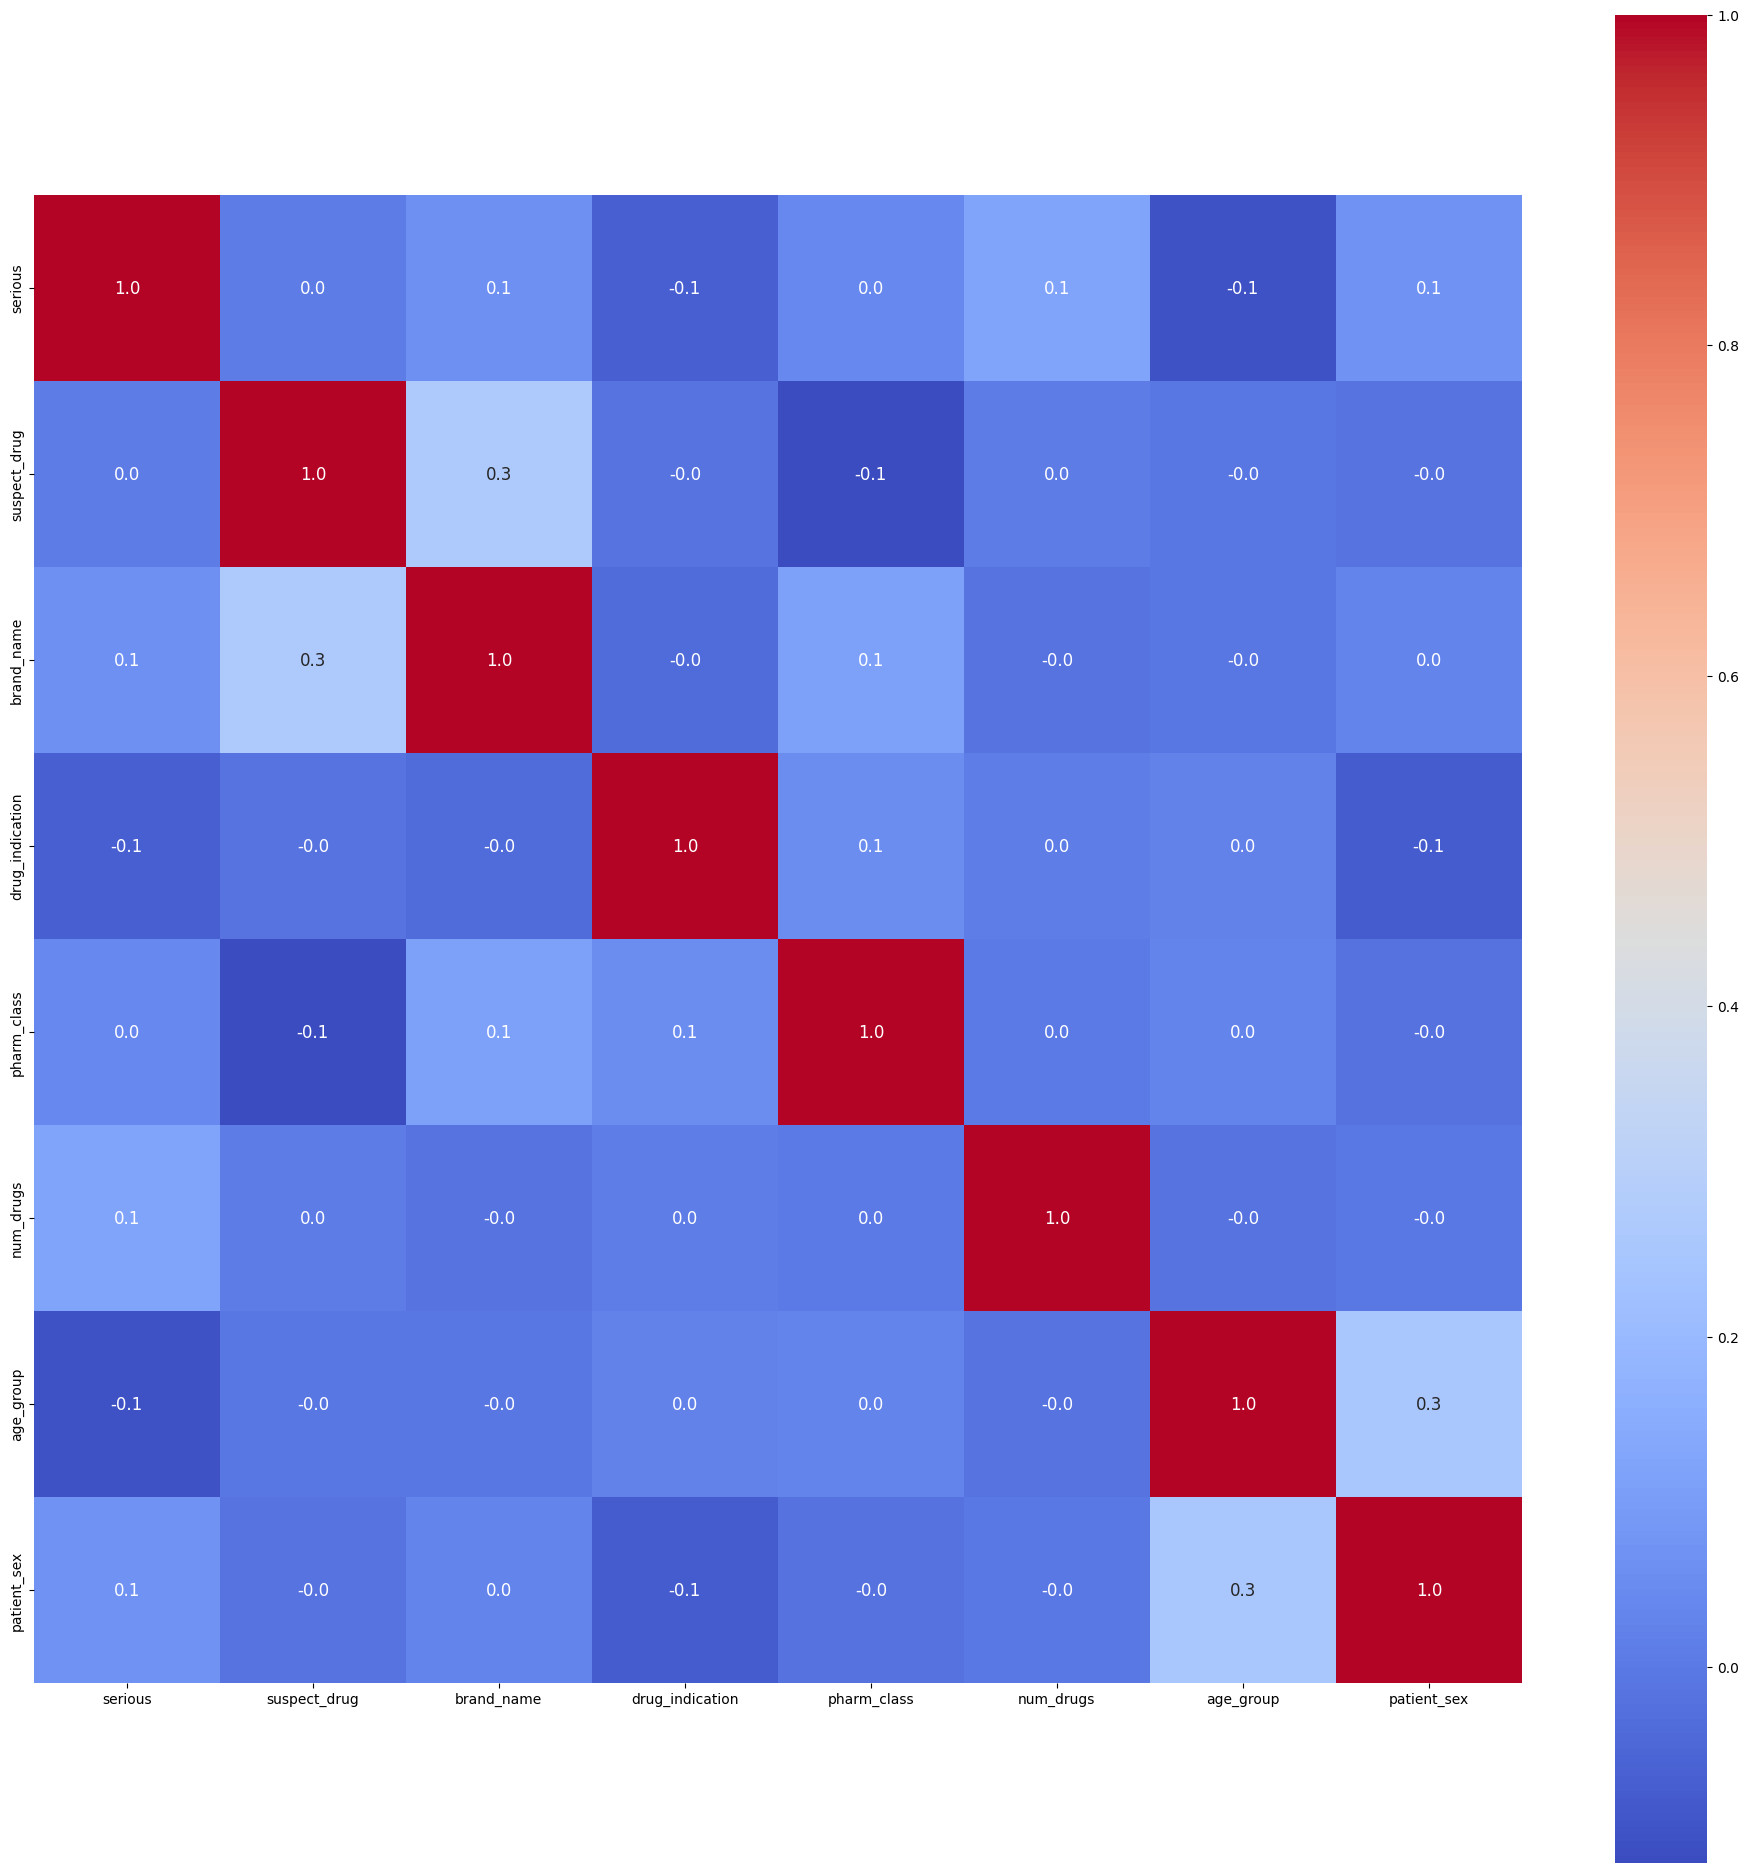

In [170]:
plt.figure(figsize=(24,24))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', 
annot=True, annot_kws={'size':12}, cmap='coolwarm')

# 🎯 Feature and Target Variable Separation

#### In this step, we separate the independent variables (features) and the dependent variable (target) for model training.

In [171]:
X = df.drop(['serious'], axis=1)  
Y = df['serious']  

In [172]:
from sklearn.model_selection import train_test_split
    # Use the original Y, not Y_scaled
X_TRAIN_RAW, X_TEST_RAW, Y_TRAIN_RAW, Y_TEST_RAW = train_test_split(X, Y, test_size=0.25, random_state=25, stratify=Y)

In [173]:
print("Size of Train X = " , len(X_TRAIN_RAW))
print("Size of Train Y = " , len(Y_TRAIN_RAW))
print("Size of Test X = " , len(X_TEST_RAW))
print("Size of Test Y = " , len(Y_TEST_RAW))

Size of Train X =  396000
Size of Train Y =  396000
Size of Test X =  132000
Size of Test Y =  132000


# ⚙️ Feature Scaling

#### In this step, we standardize the feature values using StandardScaler to ensure all features have equal importance and improve model performance.

In [174]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# ONLY scale the features (X)
X_TRAIN = scaler.fit_transform(X_TRAIN_RAW)
X_TEST = scaler.transform(X_TEST_RAW)
X_TRAIN [:1]

array([[-0.48108954,  0.50075953, -0.21653027, -0.52546628,  0.22135948,
         1.15237677, -0.85901755]])

## ⚖️ Handling Class Imbalance (Oversampling)

#### In this step, we address class imbalance in the dataset by applying RandomOverSampler to balance the minority and majority classes, which helps improve model performance.

In [175]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=25)
X_TRAIN, Y_TRAIN = ros.fit_resample(X_TRAIN, Y_TRAIN_RAW) 
Y_TEST = Y_TEST_RAW

In [176]:
print("After Oversampling:")
print(Y_TRAIN.value_counts())

After Oversampling:
serious
1    296250
0    296250
Name: count, dtype: int64


In [177]:
print(X_TRAIN.shape)
print(Y_TRAIN.shape)

(592500, 7)
(592500,)


In [178]:
print("Size of Train X = " , len(X_TRAIN))
print("Size of Train Y = " , len(Y_TRAIN))
print("Size of Test X = " , len(X_TEST))
print("Size of Test Y = " , len(Y_TEST))

Size of Train X =  592500
Size of Train Y =  592500
Size of Test X =  132000
Size of Test Y =  132000


## 🤖 Model Training

#### In this step, we train different machine learning models on the training dataset to learn patterns and make predictions.
#### 1. Guassian Naive Bayes
#### 2. Logistic Regression
#### 3. XGBoost
#### 4. Decision Tree Classifier
#### 5. Random Forest Classifier
#### 6. Multi Layer Perceptron

# 1. Guassian Naive Bayes

In [179]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_TRAIN, Y_TRAIN)
GaussianNB()

,priors,None
,var_smoothing,1e-09


## Training On TRAIN Set

In [180]:
X_train_prediction = gnb.predict(X_TRAIN)
gnb_training_data_accuracy = accuracy_score(X_train_prediction,Y_TRAIN)
print('Accuracy Score OF GNB On conda ',gnb_training_data_accuracy)

Accuracy Score OF GNB On conda  0.5732286919831223


### Confusion Matrix

In [181]:
gnb_train_cm = confusion_matrix(Y_TRAIN, X_train_prediction)
print("GNB Training Confusion Matrix:")
print(gnb_train_cm)

GNB Training Confusion Matrix:
[[277484  18766]
 [234096  62154]]


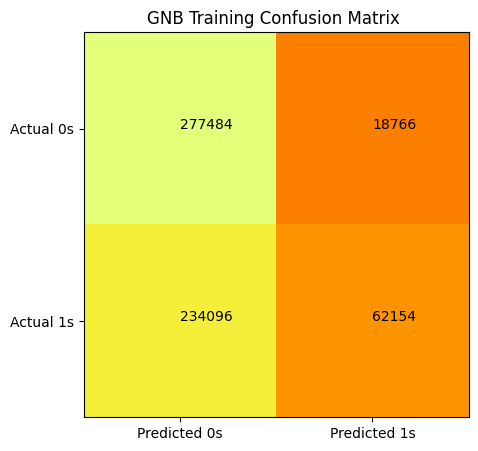

In [182]:
import matplotlib.pyplot as plt
gnb_train_cm =confusion_matrix(Y_TRAIN, X_train_prediction)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(gnb_train_cm, 'Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, gnb_train_cm[i, j], color='black')
plt.title("GNB Training Confusion Matrix ")
plt.show()

### Classification Report

In [183]:
gnb_training_report = classification_report(Y_TRAIN, X_train_prediction)
print('Classification Report Of GNB On Training')
print(gnb_training_report)

Classification Report Of GNB On Training
              precision    recall  f1-score   support

           0       0.54      0.94      0.69    296250
           1       0.77      0.21      0.33    296250

    accuracy                           0.57    592500
   macro avg       0.66      0.57      0.51    592500
weighted avg       0.66      0.57      0.51    592500



## Prediction On TEST Set

In [184]:
X_test_prediction = gnb.predict(X_TEST)
gnb_test_data_accuracy = accuracy_score(X_test_prediction,Y_TEST)
print('Accuracy Score OF GNB On Testing',gnb_test_data_accuracy)

Accuracy Score OF GNB On Testing 0.39325757575757575


### Confusion Matrix 

In [185]:
gnb_test_cm = confusion_matrix(Y_TRAIN, X_train_prediction)
print("GNB Testing Confusion Matrix:")
print(gnb_test_cm)

GNB Testing Confusion Matrix:
[[277484  18766]
 [234096  62154]]


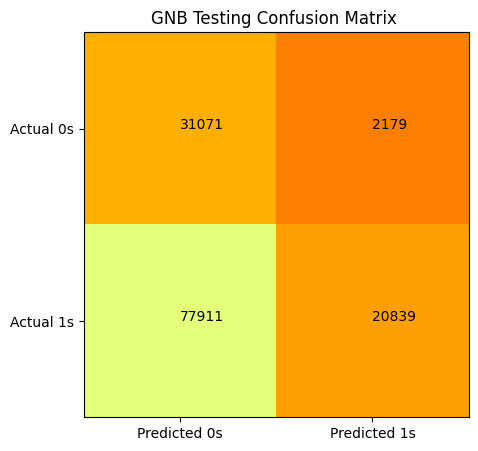

In [186]:
import matplotlib.pyplot as plt
gnb_test_cm = confusion_matrix(Y_TEST, X_test_prediction)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(gnb_test_cm, 'Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, gnb_test_cm[i, j], color='black')
plt.title("GNB Testing Confusion Matrix ")
plt.show()

### ROC_AUC Score

In [187]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# 1. Copute ROC-AUC Score
gnb_test_auc = roc_auc_score(Y_TEST, X_test_prediction)
print("ROC-AUC Score OF GNB On Testing:", gnb_test_auc)

ROC-AUC Score OF GNB On Testing: 0.5727470067573998


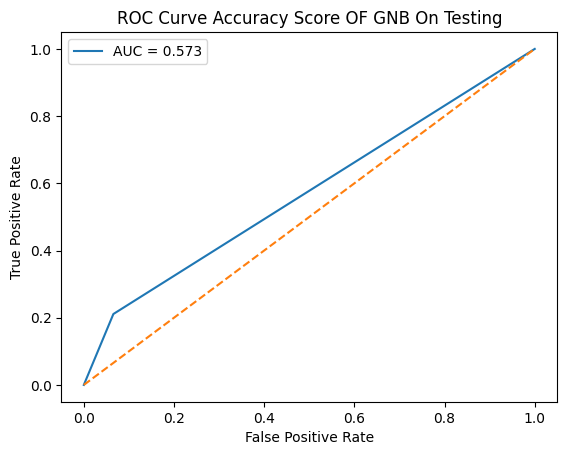

In [188]:
# 2. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(Y_TEST, X_test_prediction)

plt.plot(fpr, tpr, label=f"AUC = {gnb_test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Accuracy Score OF GNB On Testing")
plt.legend()
plt.show()

### Classification Report

In [189]:
gnb_test_report = classification_report(Y_TEST, X_test_prediction)
print('Classification Report Of GNB On Testing')
print(gnb_test_report)

Classification Report Of GNB On Testing
              precision    recall  f1-score   support

           0       0.29      0.93      0.44     33250
           1       0.91      0.21      0.34     98750

    accuracy                           0.39    132000
   macro avg       0.60      0.57      0.39    132000
weighted avg       0.75      0.39      0.37    132000



In [190]:
# Make predictions on the testing data
y_pred = gnb.predict(X_TEST)
print(y_pred)


[0 0 0 ... 0 1 0]


### Accuracy Score

In [191]:
# Accuracy score is used to check how much model's predictions are accurate.
from sklearn.metrics import accuracy_score
gnb_accuracy = accuracy_score(Y_TEST, y_pred)
print("The Accuracy of Prediction on S is ", gnb_accuracy)


The Accuracy of Prediction on S is  0.39325757575757575


# 2. Logistic Regression

In [192]:
lo  = LogisticRegression(solver='liblinear', random_state=25)
lo.fit(X_TRAIN, Y_TRAIN)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,25
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


## Training On TRAIN Set

In [193]:
X_train_prediction = lo.predict(X_TRAIN)
training_data_accuracy = accuracy_score(X_train_prediction,Y_TRAIN)
print('Accuracy Score OF Logistic Regression On Training',training_data_accuracy)

Accuracy Score OF Logistic Regression On Training 0.6470025316455696


### Confusion Matrix

In [194]:
lo_train_cm = confusion_matrix(Y_TRAIN, X_train_prediction)
print("Logistic Regression Training Confusion Matrix ")
print(lo_train_cm)

Logistic Regression Training Confusion Matrix 
[[212081  84169]
 [124982 171268]]


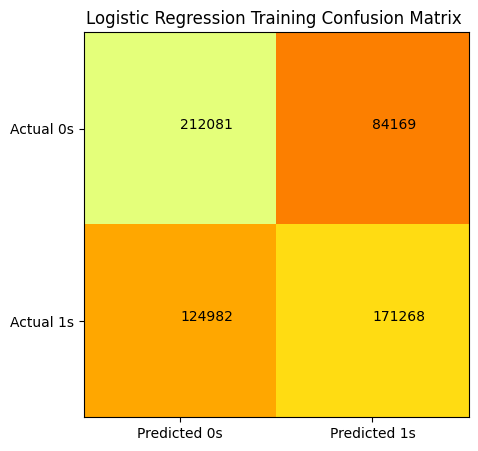

In [195]:
import matplotlib.pyplot as plt
lo_train_cm=confusion_matrix(Y_TRAIN, X_train_prediction)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(lo_train_cm, 'Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, lo_train_cm[i, j], color='black')
plt.title("Logistic Regression Training Confusion Matrix ")
plt.show()

### Classification Report

In [196]:
lo_train_report = classification_report(Y_TRAIN, X_train_prediction)
print('Classification Report Of Logistic Regression On Training')
print(lo_train_report)

Classification Report Of Logistic Regression On Training
              precision    recall  f1-score   support

           0       0.63      0.72      0.67    296250
           1       0.67      0.58      0.62    296250

    accuracy                           0.65    592500
   macro avg       0.65      0.65      0.65    592500
weighted avg       0.65      0.65      0.65    592500



## Predictions On TEST Set

In [197]:
X_test_prediction = lo.predict(X_TEST)
lo_test_data_accuracy = accuracy_score(X_test_prediction,Y_TEST)
print('Accuracy Score OF Logistic Regression On Testing',lo_test_data_accuracy)

Accuracy Score OF Logistic Regression On Testing 0.6118863636363636


### Confusion Matrix

In [198]:
lo_test_cm = confusion_matrix(Y_TEST, X_test_prediction)
print('Logistic Regression Testing Confusion Matrix')
print(lo_test_cm)

Logistic Regression Testing Confusion Matrix
[[23660  9590]
 [41641 57109]]


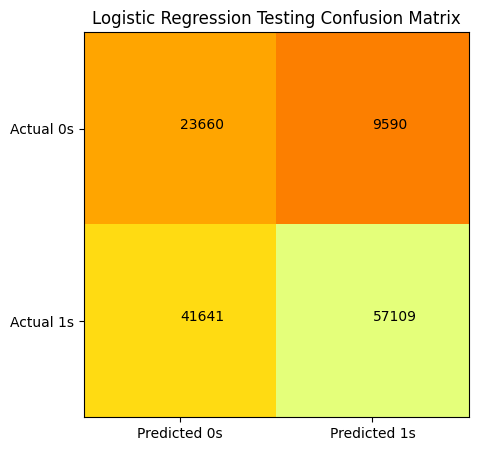

In [199]:
import matplotlib.pyplot as plt
lo_test_cm = confusion_matrix(Y_TEST, X_test_prediction)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(lo_test_cm, 'Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, lo_test_cm[i, j], color='black')
plt.title('Logistic Regression Testing Confusion Matrix')        
plt.show()

### ROC_AUC Score

In [200]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# 1. Compute ROC-AUC Score
lo_test_auc = roc_auc_score(Y_TEST, X_test_prediction)
print("ROC-AUC Score Of Logistic Regression At Testing :", lo_test_auc)

ROC-AUC Score Of Logistic Regression At Testing : 0.6449489673550967


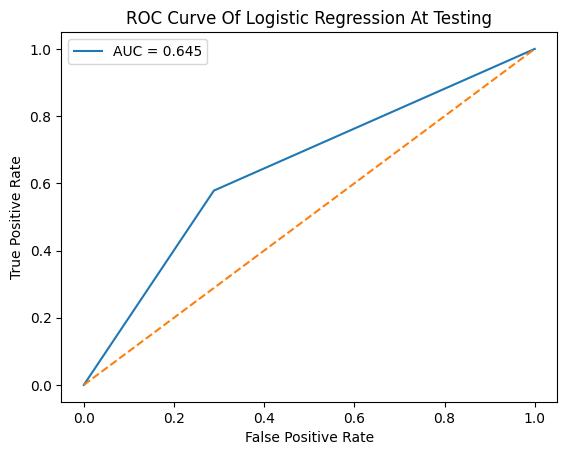

In [201]:
# 2. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(Y_TEST, X_test_prediction)

plt.plot(fpr, tpr, label=f"AUC = {lo_test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Of Logistic Regression At Testing")
plt.legend()
plt.show()

### Classification Report

In [202]:
lo_test_report = classification_report(Y_TEST, X_test_prediction)
print('Classification Report Of Logistic Regression On Testing')
print(lo_test_report)

Classification Report Of Logistic Regression On Testing
              precision    recall  f1-score   support

           0       0.36      0.71      0.48     33250
           1       0.86      0.58      0.69     98750

    accuracy                           0.61    132000
   macro avg       0.61      0.64      0.59    132000
weighted avg       0.73      0.61      0.64    132000



In [203]:
# Make predictions on the testing data
y_pred = lo.predict(X_TEST)
print(y_pred)


[1 0 1 ... 1 1 1]


### Accuracy Score

In [204]:
# Accuracy score is used to check how much model's predictions are accurate.
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TEST, y_pred)
print("The Accuracy of Prediction on S is ", accuracy)


The Accuracy of Prediction on S is  0.6118863636363636


# 3. XGBoost

In [205]:
model = xgb.XGBClassifier( 
    n_estimators = 300,
    max_depth = 5,
    learning_rate = 0.05,
    subsample = 0.5,
    colsample_bytree=0.7,
    gamma = 1,
    reg_alpha = 0.5,
    reg_lambda = 1.5,
    min_child_weight = 5,
    eval_metric = 'logloss',
    random_state=25 )
model.fit(X_TRAIN, Y_TRAIN) 

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Training On TRAIN Set

In [206]:
X_train_prediction = model.predict(X_TRAIN)
xgb_training_data_accuracy = accuracy_score(X_train_prediction,Y_TRAIN)
print('Accuracy Score OF XGBOOT On Training',xgb_training_data_accuracy)

Accuracy Score OF XGBOOT On Training 0.7868101265822784


### Confusion Matrix

In [207]:
xgb_train_cm =confusion_matrix(Y_TRAIN,X_train_prediction)
print("XGBOOST Training Confusion Matrix:")
print(xgb_train_cm)

XGBOOST Training Confusion Matrix:
[[236262  59988]
 [ 66327 229923]]


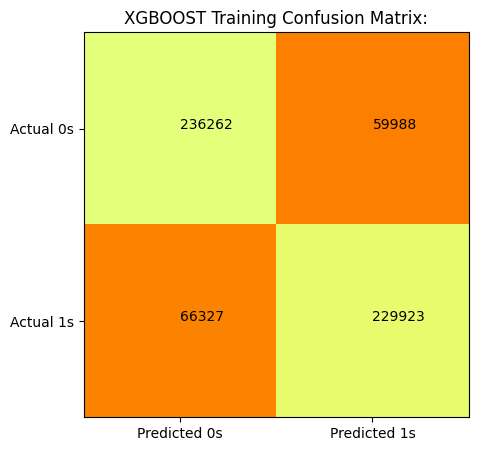

In [208]:
import matplotlib.pyplot as plt
xgb_train_cm = confusion_matrix(Y_TRAIN, X_train_prediction)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(xgb_train_cm, 'Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, xgb_train_cm[i, j], color='black')
plt.title("XGBOOST Training Confusion Matrix:")
plt.show()

### Classification Report

In [209]:
xgb_training_report = classification_report(Y_TRAIN, X_train_prediction)
print('Classification Report Of XGBOOST On Training')
print(xgb_training_report)

Classification Report Of XGBOOST On Training
              precision    recall  f1-score   support

           0       0.78      0.80      0.79    296250
           1       0.79      0.78      0.78    296250

    accuracy                           0.79    592500
   macro avg       0.79      0.79      0.79    592500
weighted avg       0.79      0.79      0.79    592500



## Prediction On TEST Set

In [210]:
X_test_prediction = model.predict(X_TEST)
xgb_test_data_accuracy = accuracy_score(X_test_prediction,Y_TEST)
print('Accuracy Score Of XGBOOST On Testing',xgb_test_data_accuracy)

Accuracy Score Of XGBOOST On Testing 0.7804545454545454


### Confusion Matrix

In [211]:
xgb_test_cm = confusion_matrix(Y_TEST,X_test_prediction)
print('XGBOOST Testing Confusion Matrix:')
print(xgb_test_cm)

XGBOOST Testing Confusion Matrix:
[[26312  6938]
 [22042 76708]]


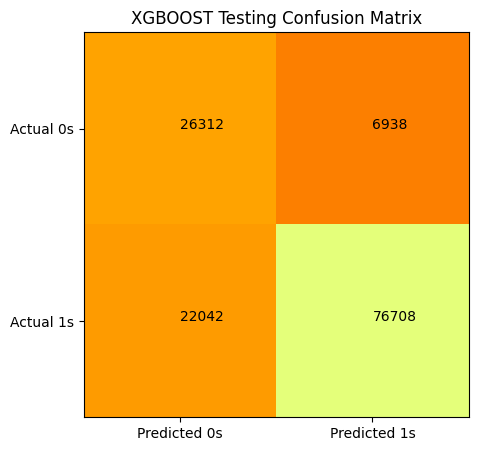

In [212]:
import matplotlib.pyplot as plt
xgb_test_cm =confusion_matrix(Y_TEST,X_test_prediction)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(xgb_test_cm, 'Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, xgb_test_cm[i, j], color='black')
plt.title('XGBOOST Testing Confusion Matrix')
plt.show()

### ROC_AUC Score

In [213]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# 1. Compute ROC-AUC Score
xgb_testing_auc = roc_auc_score(Y_TEST, X_test_prediction)
print("ROC-AUC Score Of XGBOOST On Testing:", xgb_testing_auc)


ROC-AUC Score Of XGBOOST On Testing: 0.7840641096411917


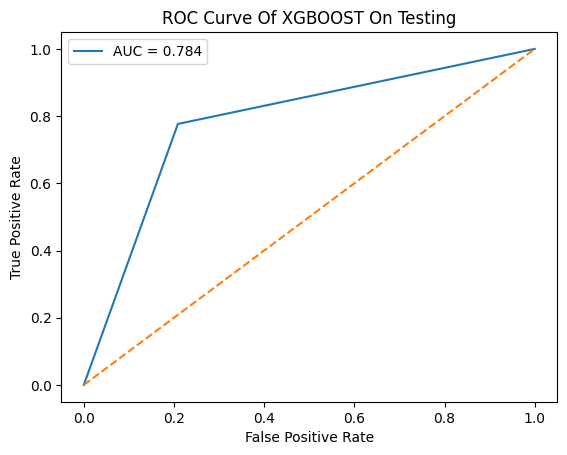

In [214]:
# 2. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(Y_TEST, X_test_prediction)

plt.plot(fpr, tpr, label=f"AUC = {xgb_testing_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Of XGBOOST On Testing")
plt.legend()
plt.show()

### Classification Report

In [215]:
xgb_test_report = classification_report(Y_TEST, X_test_prediction)
print('Classification Report Of XGBOOST On Testing')
print(xgb_test_report)

Classification Report Of XGBOOST On Testing
              precision    recall  f1-score   support

           0       0.54      0.79      0.64     33250
           1       0.92      0.78      0.84     98750

    accuracy                           0.78    132000
   macro avg       0.73      0.78      0.74    132000
weighted avg       0.82      0.78      0.79    132000



In [216]:
# Make predictions on the testing data
y_pred = model.predict(X_TEST)
print(y_pred)


[1 0 1 ... 0 1 1]


### Accuracy Score

In [217]:
# Accuracy score is used to check how much model's predictions are accurate.
from sklearn.metrics import accuracy_score
xgb_accuracy = accuracy_score(Y_TEST, y_pred)
print("The Accuracy of Prediction on S is ", xgb_accuracy)

The Accuracy of Prediction on S is  0.7804545454545454


# 4. Decision Tree

In [218]:
dtc= DecisionTreeClassifier(random_state=25)
dtc.fit(X_TRAIN, Y_TRAIN) 
DecisionTreeClassifier(random_state=25)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,25
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Training On TRAIN Set

In [219]:
X_train_prediction = dtc.predict(X_TRAIN)
training_data_accuracy = accuracy_score(X_train_prediction,Y_TRAIN)
print('Accuracy Score OF DTC On Training',training_data_accuracy)

Accuracy Score OF DTC On Training 0.9106396624472574


### Confusion Matrix

In [220]:
dtc_train_cm = confusion_matrix(Y_TRAIN,X_train_prediction)
print('DTC Training Confusion Matrix:')
print(dtc_train_cm)

DTC Training Confusion Matrix:
[[284051  12199]
 [ 40747 255503]]


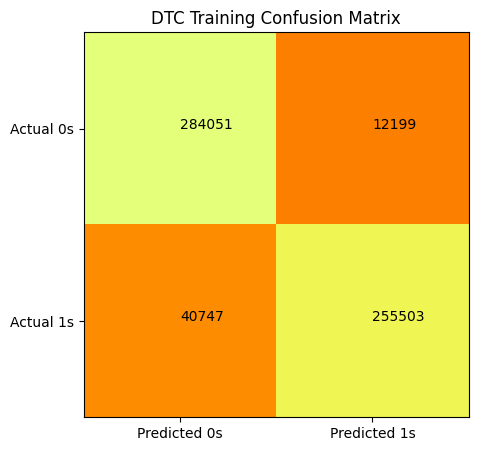

In [221]:
import matplotlib.pyplot as plt
dtc_train_cm = confusion_matrix(Y_TRAIN, X_train_prediction)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(dtc_train_cm, 'Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, dtc_train_cm[i, j], color='black')
plt.title('DTC Training Confusion Matrix')
plt.show()

### Classifiaction Report

In [222]:
dtc_train_report = classification_report(Y_TRAIN, X_train_prediction)
print('Classification Report Of DTC On Training')
print(dtc_train_report )


Classification Report Of DTC On Training
              precision    recall  f1-score   support

           0       0.87      0.96      0.91    296250
           1       0.95      0.86      0.91    296250

    accuracy                           0.91    592500
   macro avg       0.91      0.91      0.91    592500
weighted avg       0.91      0.91      0.91    592500



## Prediction On TEST Set

In [223]:
X_test_prediction = dtc.predict(X_TEST)
dtc_test_data_accuracy = accuracy_score(X_test_prediction,Y_TEST)
print('Accuracy Score Of DTC On Testing',dtc_test_data_accuracy)

Accuracy Score Of DTC On Testing 0.791060606060606


### Confusion Matrix

In [224]:
dtc_test_cm = confusion_matrix(Y_TEST,X_test_prediction)
print('DTC Testing Confusion Matrix:')
print(dtc_test_cm)

DTC Testing Confusion Matrix:
[[25258  7992]
 [19588 79162]]


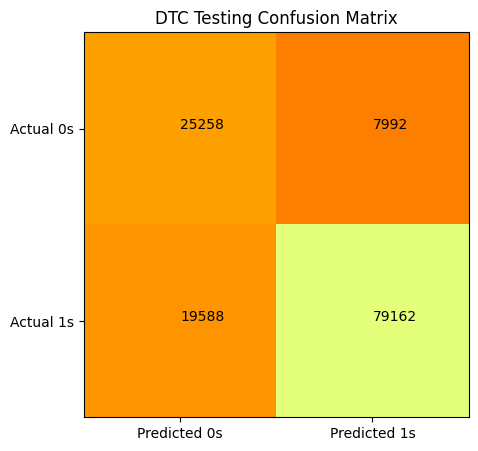

In [225]:
import matplotlib.pyplot as plt
cm =confusion_matrix(Y_TEST,X_test_prediction)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cm, 'Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], color='black')
plt.title('DTC Testing Confusion Matrix')
plt.show()

### ROC_AUC Score

In [226]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# 1. Compute ROC-AUC Score
dtc_test_auc = roc_auc_score(Y_TEST, X_test_prediction)
print("ROC-AUC Score Of DTC On Testing:", dtc_test_auc)

ROC-AUC Score Of DTC On Testing: 0.7806398020367374


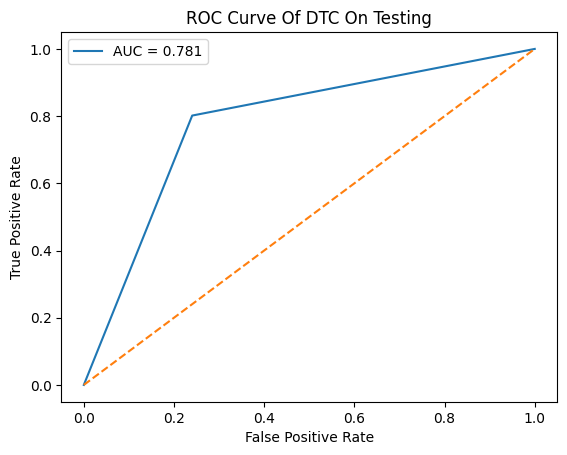

In [227]:
# 2. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(Y_TEST, X_test_prediction)

plt.plot(fpr, tpr, label=f"AUC = {dtc_test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Of DTC On Testing")
plt.legend()
plt.show()

### Classification Report

In [228]:
dtc_test_report = classification_report(Y_TEST, X_test_prediction)
print('Classification Report Of DTC On Testing')
print(dtc_test_report)

Classification Report Of DTC On Testing
              precision    recall  f1-score   support

           0       0.56      0.76      0.65     33250
           1       0.91      0.80      0.85     98750

    accuracy                           0.79    132000
   macro avg       0.74      0.78      0.75    132000
weighted avg       0.82      0.79      0.80    132000



In [229]:
# Make predictions on the testing data
y_pred = dtc.predict(X_TEST)
print(y_pred)


[1 0 1 ... 0 1 1]


### Accuracy Score

In [230]:
# Accuracy score is used to check how much model's predictions are accurate.
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TEST, y_pred)
print("The Accuracy of Prediction on S is ", accuracy)


The Accuracy of Prediction on S is  0.791060606060606


# 5. Random Forest

In [231]:
rfc = RandomForestClassifier(n_estimators=5, random_state=25)
rfc.fit(X_TRAIN, Y_TRAIN) 
RandomForestClassifier(n_estimators=5, random_state=25)

,n_estimators,5
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Training On TRAIN Set

In [232]:
X_train_prediction = rfc.predict(X_TRAIN)
rfc_train_data_accuracy = accuracy_score(X_train_prediction,Y_TRAIN)
print('Accuracy Score OF RFC ON Training',rfc_train_data_accuracy)

Accuracy Score OF RFC ON Training 0.9060540084388186


### Confusion Matrix

In [233]:
rfc_train_cm = confusion_matrix(Y_TRAIN,X_train_prediction)
print('RFC Training Confusion Matrix:')
print(rfc_train_cm)

RFC Training Confusion Matrix:
[[280943  15307]
 [ 40356 255894]]


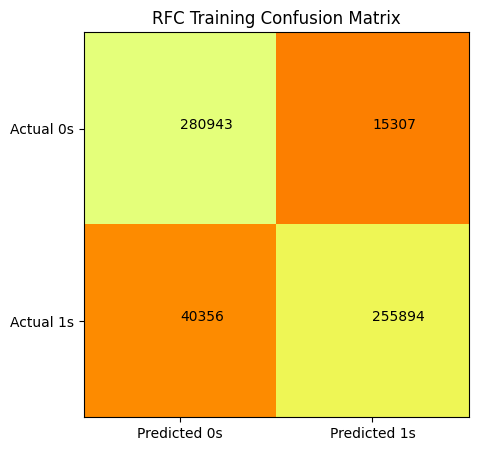

In [234]:
import matplotlib.pyplot as plt
rfc_train_cm = confusion_matrix(Y_TRAIN,X_train_prediction)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rfc_train_cm, 'Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, rfc_train_cm[i, j], color='black')
plt.title('RFC Training Confusion Matrix')    
plt.show()

### Classifiaction Report

In [235]:
rfc_train_report = classification_report(Y_TRAIN, X_train_prediction)
print('Classification Report Of RFC On Training')
print(rfc_train_report)

Classification Report Of RFC On Training
              precision    recall  f1-score   support

           0       0.87      0.95      0.91    296250
           1       0.94      0.86      0.90    296250

    accuracy                           0.91    592500
   macro avg       0.91      0.91      0.91    592500
weighted avg       0.91      0.91      0.91    592500



## Predictions On TEST Set

In [236]:
X_test_prediction = rfc.predict(X_TEST)
rfc_test_data_accuracy = accuracy_score(X_test_prediction,Y_TEST)
print('Accuracy Score Test Data',rfc_test_data_accuracy)

Accuracy Score Test Data 0.7989848484848485


### Confusion Matrix

In [237]:
rfc_test_cm = confusion_matrix(Y_TEST,X_test_prediction)
print('RFC Testing Confusion Matrix:')
print(rfc_test_cm)

RFC Testing Confusion Matrix:
[[25035  8215]
 [18319 80431]]


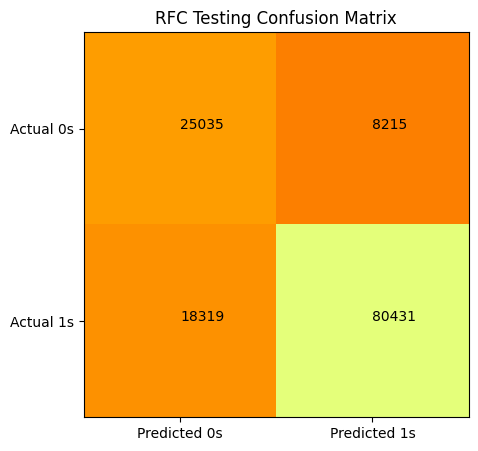

In [238]:
import matplotlib.pyplot as plt
rfc_test_cm =confusion_matrix(Y_TEST, X_test_prediction)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rfc_test_cm, 'Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, rfc_test_cm[i, j], color='black')
plt.title('RFC Testing Confusion Matrix')        
plt.show()

### ROC_AUC Score

In [239]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# 1. Compute ROC-AUC Score
rfc_test_auc = roc_auc_score(Y_TEST, X_test_prediction)
print("ROC-AUC Score Of RFC On Testing:", rfc_test_auc)


ROC-AUC Score Of RFC On Testing: 0.783711735033787


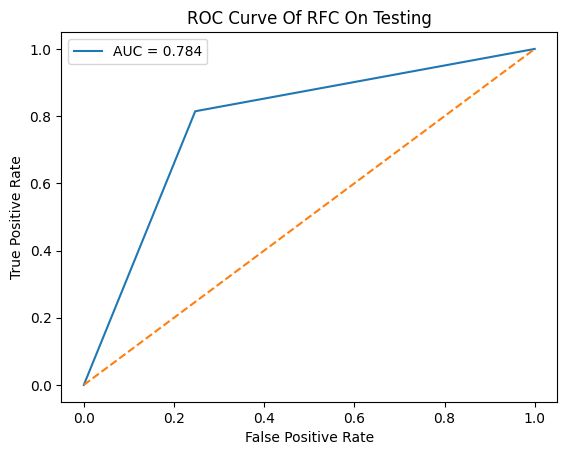

In [240]:
# 2. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(Y_TEST, X_test_prediction)

plt.plot(fpr, tpr, label=f"AUC = {rfc_test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Of RFC On Testing")
plt.legend()
plt.show()

### Classification Report

In [241]:
rfc_test_report = classification_report(Y_TEST, X_test_prediction)
print('Classification Report Of RFC In Testing')
print(rfc_test_report)

Classification Report Of RFC In Testing
              precision    recall  f1-score   support

           0       0.58      0.75      0.65     33250
           1       0.91      0.81      0.86     98750

    accuracy                           0.80    132000
   macro avg       0.74      0.78      0.76    132000
weighted avg       0.82      0.80      0.81    132000



In [242]:
# Make predictions on the testing data
y_pred = rfc.predict(X_TEST)
print(y_pred)


[1 0 1 ... 0 1 1]


### Accuracy Score

In [243]:
# Accuracy score is used to check how much model's predictions are accurate.
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TEST, y_pred)
print("The Accuracy of Prediction on S is ", accuracy)


The Accuracy of Prediction on S is  0.7989848484848485


# NEURAL NETWORKS (MULTI LAYER Perceptron)

In [244]:
pt = PowerTransformer()
X_TRAIN_PT = pt.fit_transform(X_TRAIN_RAW)
X_TEST_PT = pt.transform(X_TEST_RAW)


In [245]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=25)
X_TRAIN_res, Y_TRAIN_res = ros.fit_resample(X_TRAIN_PT, Y_TRAIN_RAW) 


In [246]:
print(X_TRAIN_res.shape)
print(Y_TRAIN_res.shape)

(592500, 7)
(592500,)


In [247]:
# 2. Stronger Model Architecture
mlp= models.Sequential([
    layers.Input(shape=(X_TRAIN_res.shape[1],)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), # Keeps weights stable
    layers.Dropout(0.3),   # Increased to prevent overfitting
    
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    
    layers.Dense(1, activation='sigmoid')
])

mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [248]:
# 3. The "Smart" Training Callbacks
# This reduces the learning rate when the model stops improving
lr_reducer = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = mlp.fit(
    X_TRAIN_res, Y_TRAIN_res,
    epochs=100, # More epochs because LR Reducer will handle the slowdown
    validation_split=0.2,
    callbacks=[lr_reducer, early_stop],
    verbose=1
)

Epoch 1/100
14813/14813 [==============================] - 157s 10ms/step - loss: 0.5282 - accuracy: 0.7354 - val_loss: 0.7152 - val_accuracy: 0.6286 - lr: 0.0010
Epoch 2/100
14813/14813 [==============================] - 156s 11ms/step - loss: 0.4897 - accuracy: 0.7610 - val_loss: 0.7043 - val_accuracy: 0.6356 - lr: 0.0010
Epoch 3/100
14813/14813 [==============================] - 153s 10ms/step - loss: 0.4746 - accuracy: 0.7699 - val_loss: 0.6193 - val_accuracy: 0.6946 - lr: 0.0010
Epoch 4/100
14813/14813 [==============================] - 149s 10ms/step - loss: 0.4648 - accuracy: 0.7759 - val_loss: 0.7349 - val_accuracy: 0.6337 - lr: 0.0010
Epoch 5/100
14813/14813 [==============================] - 148s 10ms/step - loss: 0.4571 - accuracy: 0.7802 - val_loss: 0.6495 - val_accuracy: 0.6780 - lr: 0.0010
Epoch 6/100
14813/14813 [==============================] - 154s 10ms/step - loss: 0.4512 - accuracy: 0.7838 - val_loss: 0.5869 - val_accuracy: 0.7141 - lr: 0.0010
Epoch 7/100
14813/1481

## Training  On TRAIN Set

In [249]:
# Accessing the very last entry in the accuracy list
mlp_train_data_accuracy  = history.history['accuracy'][-1]
print('Accuracy Score OF MLP ON Training',mlp_train_data_accuracy)

Accuracy Score OF MLP ON Training 0.8170675039291382


### Confusion Matrix

In [250]:
# Probabilities
y_train_prob = mlp.predict(X_TRAIN_res)

# Convert to 0/1 using threshold 0.5
X_train_prediction = (y_train_prob > 0.5).astype(int)

18516/18516 [==============================] - 59s 3ms/step


In [251]:
mlp_train_cm = confusion_matrix(Y_TRAIN_res, X_train_prediction)
print('MLP Training Confusion Matrix:')
print(mlp_train_cm)

MLP Training Confusion Matrix:
[[228652  67598]
 [ 46034 250216]]


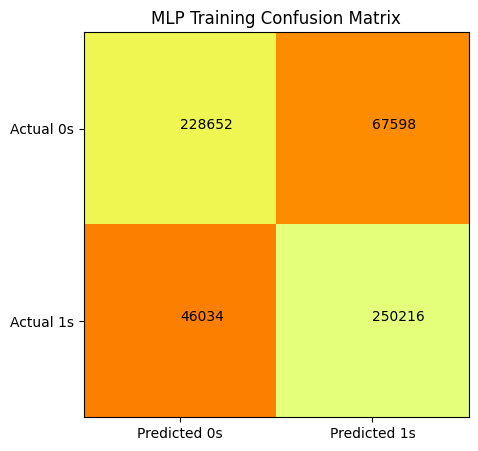

In [252]:
import matplotlib.pyplot as plt
mlp_train_cm = confusion_matrix(Y_TRAIN_res, X_train_prediction)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(mlp_train_cm, cmap='Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, mlp_train_cm[i, j], color='black')
plt.title('MLP Training Confusion Matrix')       
plt.show()

### Classification Report

In [253]:
from sklearn.metrics import classification_report

# Step 1: Predict probabilities
X_train_prob = mlp.predict(X_TRAIN_res)

18516/18516 [==============================] - 62s 3ms/step


In [254]:
# Step 2: Convert to 0/1
X_train_prediction = (X_train_prob > 0.5).astype(int).flatten()

In [255]:
# Step 3: Classification report 6 layers
mlp_train_report = classification_report(Y_TRAIN_res, X_train_prediction)
print('Classification Report Of MLP On Training')
print(mlp_train_report)

Classification Report Of MLP On Training
              precision    recall  f1-score   support

           0       0.83      0.77      0.80    296250
           1       0.79      0.84      0.81    296250

    accuracy                           0.81    592500
   macro avg       0.81      0.81      0.81    592500
weighted avg       0.81      0.81      0.81    592500



## Testing On TEST Set

In [257]:
# Unpack the list returned by .evaluate()
mlp_test_data_loss, mlp_test_data_accuracy = mlp.evaluate(X_TEST_PT, Y_TEST_RAW, verbose=0)

# Print on separate lines
print(f'Testing Loss In MLP:     {mlp_test_data_loss:}')
print(f'Testing Accuracy Of MLP On testing: {mlp_test_data_accuracy:}')

Testing Loss In MLP:     0.390446275472641
Testing Accuracy Of MLP On testing: 0.8135985136032104


### Confusion Matrix 

In [259]:
y_test_prob = mlp.predict(X_TEST_PT)
X_test_prediction = (y_test_prob > 0.5).astype(int).flatten()

4125/4125 [==============================] - 14s 3ms/step


In [260]:
mlp_test_cm = confusion_matrix(Y_TEST_RAW, X_test_prediction)
print('MLP Testing Confusion Matrix:')
print(mlp_test_cm)


MLP Testing Confusion Matrix:
[[24643  8607]
 [15998 82752]]


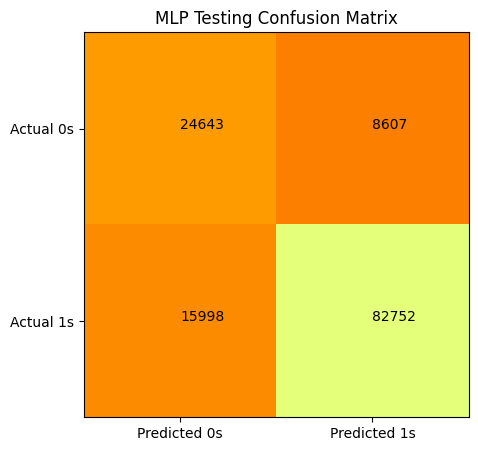

In [261]:
import matplotlib.pyplot as plt
mlp_test_cm = confusion_matrix(Y_TEST_RAW, X_test_prediction)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(mlp_test_cm, 'Wistia_r')
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, mlp_test_cm[i, j], color='black')
plt.title('MLP Testing Confusion Matrix')
plt.show()

### ROC_AUC Score

In [262]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# 1. Compute ROC-AUC Score
mlp_test_auc = roc_auc_score(Y_TEST_RAW, X_test_prediction)
print("ROC-AUC Score Of MLP On Testing:", mlp_test_auc)

ROC-AUC Score Of MLP On Testing: 0.789568896925859


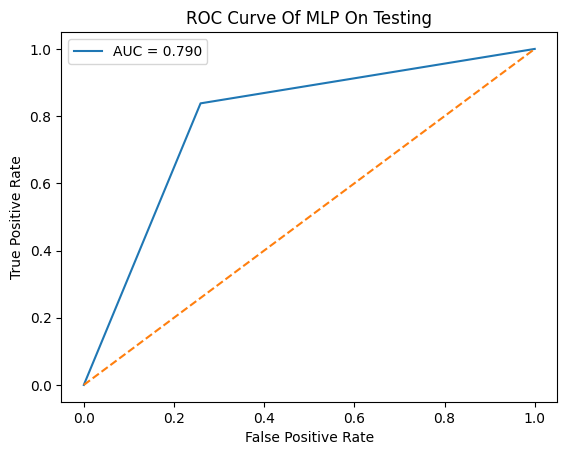

In [263]:
# 2. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(Y_TEST_RAW, X_test_prediction)

plt.plot(fpr, tpr, label=f"AUC = {mlp_test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Of MLP On Testing")
plt.legend()
plt.show()

### Classification Report

In [264]:
y_test_prob = mlp.predict(X_TEST_PT)
X_test_prediction = (y_test_prob > 0.5).astype(int).flatten()

4125/4125 [==============================] - 16s 4ms/step


In [266]:
mlp_test_report = classification_report(Y_TEST_RAW, X_test_prediction)
print('Classification Report Of MLP On Testing')
print(mlp_test_report)

Classification Report Of MLP On Testing
              precision    recall  f1-score   support

           0       0.61      0.74      0.67     33250
           1       0.91      0.84      0.87     98750

    accuracy                           0.81    132000
   macro avg       0.76      0.79      0.77    132000
weighted avg       0.83      0.81      0.82    132000



### Accuracy Score

In [267]:
y_pred_prob = mlp.predict(X_TEST_PT)
y_pred_class = (y_pred_prob > 0.5).astype(int).flatten()
print(y_pred_class)

4125/4125 [==============================] - 14s 3ms/step
[1 0 1 ... 0 1 1]


### Accuracy Report

In [268]:
accuracy = accuracy_score(Y_TEST_RAW, y_pred_class)
print("Accuracy:", accuracy)

Accuracy: 0.8135984848484848


## Comparison Graph

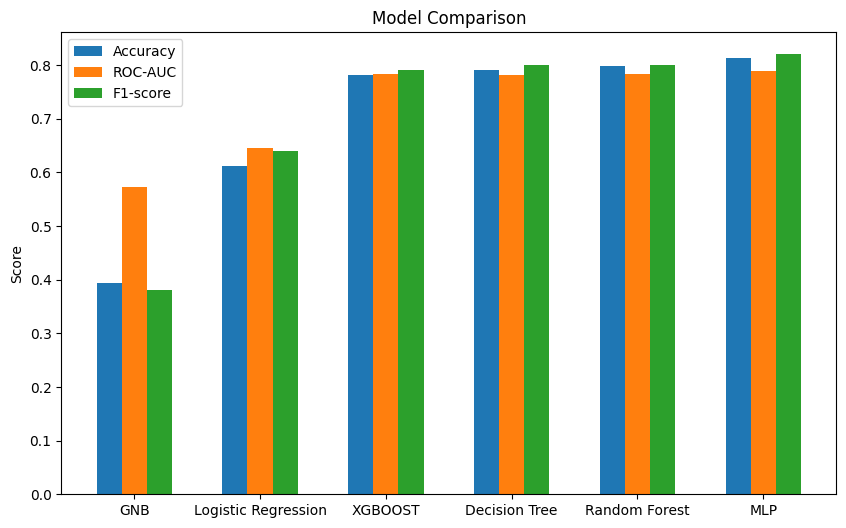

In [269]:
import matplotlib.pyplot as plt

models = ["GNB", "Logistic Regression", "XGBOOST", "Decision Tree", "Random Forest", "MLP"]

accuracy = [gnb_test_data_accuracy,
            lo_test_data_accuracy,
            xgb_test_data_accuracy,
            dtc_test_data_accuracy,
            rfc_test_data_accuracy,
            mlp_test_data_accuracy
           ]
roc_auc  = [gnb_test_auc, lo_test_auc, xgb_testing_auc, dtc_test_auc, rfc_test_auc
            , mlp_test_auc
           ]
f1_score = [0.38, 0.64, 0.79, 0.80, 0.80,
            0.82
           ]

x = range(len(models))

plt.figure(figsize=(10,6))

plt.bar(x, accuracy, width=0.2, label="Accuracy")
plt.bar([i+0.2 for i in x], roc_auc, width=0.2, label="ROC-AUC")
plt.bar([i+0.4 for i in x], f1_score, width=0.2, label="F1-score")

plt.xticks([i+0.2 for i in x], models)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.show()

In [219]:
mlp.fit(X_TRAIN_res, Y_TRAIN_res)
mlp.save("model.keras")

18516/18516 [==============================] - 150s 8ms/step - loss: 0.4177 - accuracy: 0.8043


In [206]:
import joblib
joblib.dump(pt, 'transformer.joblib')

['transformer.joblib']

In [198]:
df.columns

Index(['serious', 'suspect_drug', 'brand_name', 'drug_indication',
       'pharm_class', 'num_drugs', 'drug_count_category', 'age_group',
       'patient_sex'],
      dtype='object')